In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
df = df.drop_duplicates()

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

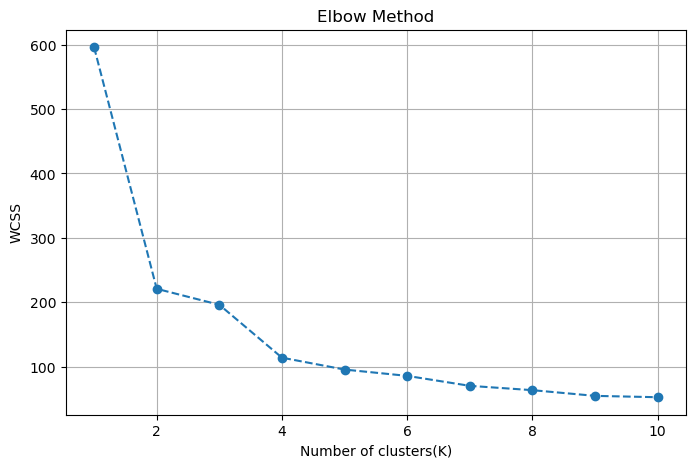

In [8]:
# elbow method
wcss=[]
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# plotting elbow graph
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o', linestyle='--')
plt.title("Elbow Method")
plt.xlabel("Number of clusters(K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [9]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [10]:
df["Clusters"] = clusters

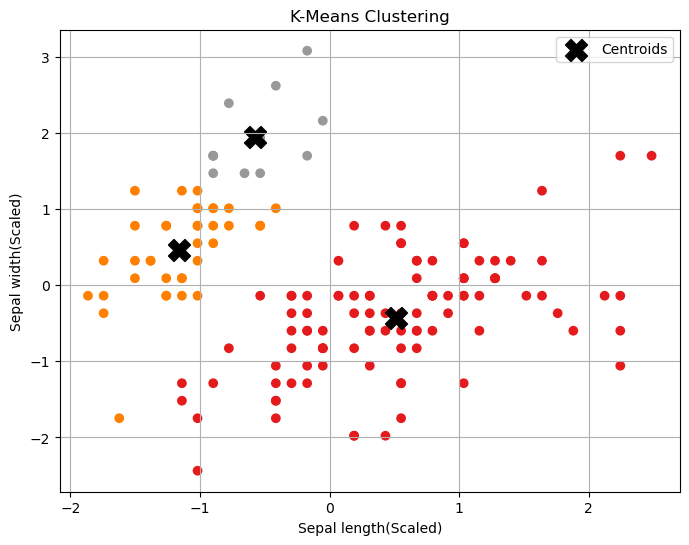

In [11]:
# visualising clusters 
plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    cmap='Set1',
    marker='o'
)
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=250,
    color='black',
    marker='X',
    label='Centroids'
)
plt.title("K-Means Clustering")
plt.xlabel("Sepal length(Scaled)")
plt.ylabel("Sepal width(Scaled)")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
#  applying pca
from sklearn.decomposition import PCA

In [13]:
pca = PCA(n_components=2)
pca_data= pca.fit_transform(X_scaled)
print("Shape after pca:" ,pca_data.shape)

Shape after pca: (149, 2)


In [14]:
centers_pca = pca.transform(kmeans.cluster_centers_)

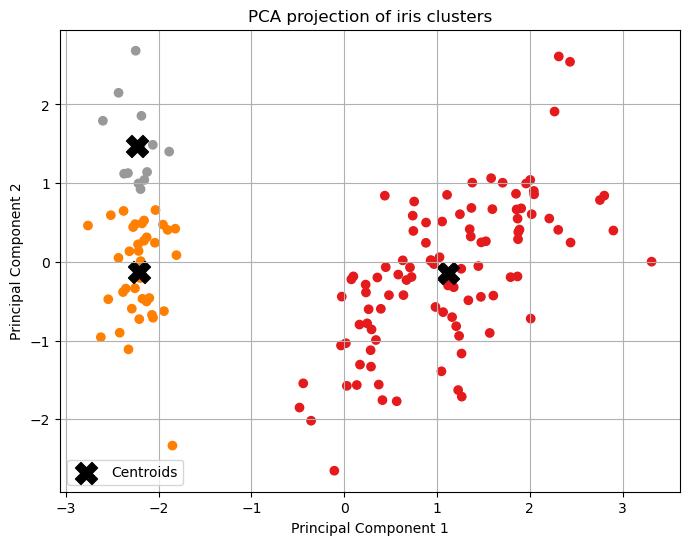

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=clusters,
    cmap='Set1',
    marker='o'
)
plt.scatter(
    centers_pca[:,0],
    centers_pca[:,1],
    s=250,
    marker='X',
    color='black',
    label='Centroids'
)
plt.title("PCA projection of iris clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()
